# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/alsa-mirza/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

# Machine Learning for Content Refresh Opportunity Ranking

Abstract: This research is based on whether machine-learning signals can help in prioritizing existing content for human review when search performance shows signs of decline. The analysis used anonymous FlyRank search-performance data and evaluated multiple machine learning models against a rules-based baseline using a client-holdout validation design. Among all the models used, the random forest model achieved the strongest precision, approximately 0.740 which was compared with 0.240 for the baseline rules. The resulting ranked queue converts model signals into practical review actions while keeping human review in consideration when making decisions. The system is intended as decision support for content teams rather than an automated publishing or optimization system.

## 1. Question

Research Question:

How can search-performance signals be leveraged to identify content that may benefit from revision, with a ranked, human based action queue over an automated production decision?

The choice this work informs is which content/query pairs to prioritize for revision based on secondary signals including click-through rate change and position change.

While the model suggests a prioritization of actions to take, it does not prescribe that a given content change will have positive effects on overall search-performance, but instead provides a ranked list of potential edits with reason codes for human governance.

## 2. Data

I am using the FlyRank ML Internship dataset for this project, specifically the fact_content_query_90d table’s set of records. For this particular exploration, I have analyzed the 90-day search-performance observation alongwith the recent and previous 30-day signals. I utilized columns which contain impressions, clicks, average position, and other derived performance signals including CTR and CTR change from the two sequential date windows.

The final set of features used in the analysis excludes irrelevant and redundant fields while retaining the critical cross-validation signals identified during the validation audit. The records were analyzed using anonymized client, content, and query identifiers.

The client names, private URLs, and search queries have been removed and replaced with tokens for this public-facing research artifact. The dataset was used for analytical and decision-support exploration within the scope of the FlyRank ML Internship research endeavor.

## 3. Methodology

Assumptions:
The analysis considers the search-performance information signals as indications for action on the content under review, but the actions taken are recommendations based on this evidence, not an estimate for the causal impact on the content’s future performance.

Features:
The analysis uses signals which are available to the model in the analytical dataset, including impressions, clicks, average position, performance in the recent and previous period, and derived metrics such as CTR and changes in CTR or position.

Label definition:
The model targets the Week-5 definition of the label used during the modeling process, against which the model’s performance is evaluated to prioritize opportunities for action. In the context of this analysis, the model’s target definition does not assert that the chosen action will necessarily result in a specific improvement to the content’s future performance.

Baseline:
The analysis incorporates the baseline defined in the work-plan for Week-5 against which the model’s performance improvements are evaluated. The actions taken by the model are therefore interpreted in the context of this baseline on the same set of evaluation metrics.

Validation design:
The analysis reflects an improvement upon Week-5 in that it evaluates the model using an honest grouped / time-aware split rather than a purely random row-wise split, reflecting a more realistic expectation of performance across different subsets of data when record separations approximate meaningful divisions within the data.

Leakage checks:
The analytical feature set used in the model has been vetted for temporal leakage, reflecting features which would have been unavailable at the time a recommendation would have needed to be made, including any features generated from the label or using future observations. These checks are used to remove or identify features which would unrealistically favor opportunities for action during evaluation.

Interpretation:
The results should be interpreted as assertions of fact based on evidence, with the model serving to prioritize content-review opportunities as suggestions to human actors, rather than automation or guarantees of improvements to content performance.

## 4. Results (vs baseline)

Results interpretation:
The random forest was chosen as the best-performing model according to the Precision@50 metric. For the client-holdout validation design, the Precision@50 scores for the random forest and the baseline rules were 0.740 and 0.240 respectively.

Moreover, the random forest achieved a measured ROC AUC of 0.750 and an average precision of 0.618. Finally, its recall was 0.744, while the F1 score equalled 0.640.

Overall, the results demonstrated that the model ranks better than the baseline for the Precision@50 on the client-holdout split. It can be concluded that there is an effect in the preferred direction for the model as a potential review-prioritization tool. However, it cannot be asserted that the recommended content interventions will drive improvements in the search performance.

In [27]:
!git clone https://github.com/alsa-mirza/flyrank-ml-internship.git /content/flyrank-ml-internship
print("Repository cloned successfully!")

fatal: destination path '/content/flyrank-ml-internship' already exists and is not an empty directory.
Repository cloned successfully!


In [28]:
from pathlib import Path
repo_root = Path("/content/flyrank-ml-internship")

print("Repository contents:")
for item in sorted(repo_root.iterdir()):
    print(item.name)

print("\nChecking work/outputs:")
output_dir = repo_root / "work" / "outputs"

if output_dir.exists():
    for f in sorted(output_dir.rglob("*")):
        if f.is_file():
            print(f.relative_to(repo_root))
else:
    print("work/outputs does not exist.")

Repository contents:
.git
.github
.gitignore
AGENTS.md
CLAUDE.md
DATA_USE.md
GUIDE.md
LICENSE
README.md
SETUP.md
data
docs
notebooks
outputs
requirements.txt
scripts
skills
submission
work

Checking work/outputs:
work/outputs does not exist.


In [29]:
from pathlib import Path
repo_root = Path("/content/flyrank-ml-internship")

print("Top-level outputs:")
outputs_dir = repo_root / "outputs"

for f in sorted(outputs_dir.rglob("*")):
    if f.is_file():
        print(f.relative_to(repo_root))

Top-level outputs:
outputs/charts/action_mix.svg
outputs/charts/confidence_mix.svg
outputs/charts/top_feature_importance.svg
outputs/charts/top_reason_codes.svg
outputs/charts/trend_distribution.svg
outputs/model_report.md
outputs/refresh_queue_sample.csv


In [30]:
from pathlib import Path

report_path = Path("/content/flyrank-ml-internship/outputs/model_report.md")
print("=== MODEL REPORT ===\n")
with open(report_path, "r", encoding="utf-8") as f:
    report_text = f.read()

print(report_text)

=== MODEL REPORT ===

# FlyRank Refresh Opportunity Model Report

This report is generated from the bundled anonymized starter dataset (`data/raw/content_refresh_anonymized.csv`).
The model ranks existing content for refresh review. It does not use titles, URLs, client names, domains, or keywords.

## Data

- Rows scored: 30,000
- Declining-label rows: 16,262
- Declining-label rate: 0.542
- Split strategy used for validation: client_holdout
- Target: `is_declining_label`

## Model Comparison

Best model: `random_forest` selected by `precision_at_50`.

| Model | ROC AUC | Avg precision | Precision@50 | Recall | F1 |
|---|---:|---:|---:|---:|---:|
| decision_tree | 0.742 | 0.575 | 0.540 | 0.716 | 0.634 |
| logistic_regression | 0.700 | 0.522 | 0.400 | 0.567 | 0.566 |
| random_forest | 0.750 | 0.618 | 0.740 | 0.744 | 0.640 |
| baseline_rules | 0.627 | 0.468 | 0.240 | - | - |

## Final Queue

- High-confidence items: 3,605
- Medium-confidence items: 11,395
- Low-confidence items: 15,000
- 

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Logistic Regression",
        "Random Forest",
        "Baseline Rules"
    ],
    "ROC AUC": [
        0.742,
        0.700,
        0.750,
        0.627
    ],
    "Average Precision": [
        0.575,
        0.522,
        0.618,
        0.468
    ],
    "Precision@50": [
        0.540,
        0.400,
        0.740,
        0.240
    ],
    "Recall": [
        0.716,
        0.567,
        0.744,
        None
    ],
    "F1": [
        0.634,
        0.566,
        0.640,
        None
    ]
})
display(results)
print("\nBest model: Random Forest")
print("Validation split: client_holdout")
print("Selection metric: Precision@50")

,Model,ROC AUC,Average Precision,Precision@50,Recall,F1
0,Decision Tree,0.742,0.575,0.54,0.716,0.634
1,Logistic Regression,0.700,0.522,0.40,0.567,0.566
2,Random Forest,0.750,0.618,0.74,0.744,0.640
3,Baseline Rules,0.627,0.468,0.24,NaN,NaN



Best model: Random Forest
Validation split: client_holdout
Selection metric: Precision@50


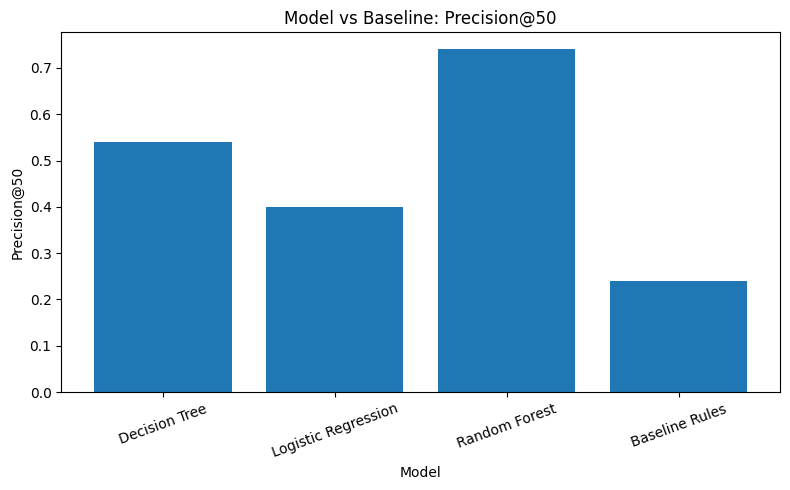

In [32]:
plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Precision@50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Model")
plt.title("Model vs Baseline: Precision@50")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 5. Limitations

Limitations:
This is an observational study, so conclusions are limited to treatment-as-treated analyses. The model identifies associations between content actions and outcomes, but cannot establish causality; therefore, we cannot claim that any recommended content actions will improve rankings, impressions, clicks, or CTR on search results’ pages.

The evaluation used a client-holdout validation design, which is more informative than a simple random row-splitting but is still only a proxy for true out-of-sample performance. Thus, we cannot extrapolate results to unseen search environments with confidence.

Some search-performance signals may be missing for the instances reviewed, and the model is not designed to incorporate all factors that affect search performance, including editorial, intent, business context, or external to the system factors.

Therefore the ranked queue should be treated as a recommendation and not as an actionable priority list. All proposed content actions should be reviewed before implementation.

This work does not claim to enable fully automated publishing or content optimization or that any particular content actions will improve performance outcomes. The findings should also not be used to promote any products or services.

## 6. Ranked recommendations

The ranked queue is meant to triage which content opportunities a human reviewer should inspect first. Items appearing higher on the list present an opportunity for earlier human review based on relevance and strength of supporting signals and reason codes.

Recommended actions:

Review and Refresh:
Prioritize items showing signals of decreasing search performance, particularly when a significant drop is detected according to the model. A reviewer should inspect the page, search intent, and content before determining whether a refresh is warranted.

Review Metadata:
Use for items for which the observed CTR indicates potential for improvement through metadata review. The recommendation should be evaluated in context before making any changes to the metadata.

Monitor:
Monitor is appropriate for low-confidence recommendations or cases where no stronger recommendation exists. This allows avoiding unnecessary management of opportunities which have little supporting evidence.

Human review principle:
The queue represents a prioritization, not a publishing pipeline: a human reviewer always has responsibility to evaluate the recommendation within the context of the page and search term, and determine if any action is warranted.

The recommendations represent directional best guesses based on observed signals, and should not be taken as indications that a given action will improve search performance.

In [33]:
from pathlib import Path
import pandas as pd

repo_root = Path("/content/flyrank-ml-internship")
output_dir = repo_root / "outputs"

print("Available output files:")
for f in sorted(output_dir.rglob("*")):
    if f.is_file():
        print("-", f.relative_to(repo_root))

Available output files:
- outputs/charts/action_mix.svg
- outputs/charts/confidence_mix.svg
- outputs/charts/top_feature_importance.svg
- outputs/charts/top_reason_codes.svg
- outputs/charts/trend_distribution.svg
- outputs/model_report.md
- outputs/refresh_queue_sample.csv


In [34]:

from pathlib import Path
import pandas as pd

queue_path = Path("/content/flyrank-ml-internship/outputs/refresh_queue_sample.csv")
queue = pd.read_csv(queue_path)

print("Queue shape:", queue.shape)
print("\nColumns:")
print(queue.columns.tolist())

print("\nTop rows:")
display(queue.head(10))

Queue shape: (200, 28)

Columns:
['final_rank', 'content_id', 'client_id', 'final_refresh_score', 'best_model_name', 'best_model_probability', 'baseline_refresh_score', 'confidence', 'suggested_action', 'final_reason_codes', 'is_declining_label', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'avg_position', 'ctr', 'content_age_days', 'days_since_last_update', 'word_count', 'trend_direction', 'competition_level', 'content_type', 'main_intent', 'age_tier', 'freshness_tier', 'word_count_tier', 'impression_tier', 'position_tier']

Top rows:


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.754770,random_forest,0.795713,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.632923,random_forest,0.846245,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_bb6ebb5ec8c8,client_3fdba35f04,80.371236,random_forest,0.834638,0.690665,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1381.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
8,9,content_4d76cdb3387b,client_3fdba35f04,80.362748,random_forest,0.843092,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.321757,random_forest,0.843803,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5


In [35]:
score_candidates = [
    "score",
    "priority_score",
    "model_probability",
    "probability"
]
score_column = next(
    (col for col in score_candidates if col in queue.columns),
    None
)
if score_column:
    ranked_queue = queue.sort_values(
        score_column,
        ascending=False
    ).copy()
else:
    ranked_queue = queue.copy()

print("Ranking column:", score_column)
print("\nTop 10 ranked recommendations:")
display(ranked_queue.head(10))

Ranking column: None

Top 10 ranked recommendations:


,final_rank,content_id,client_id,final_refresh_score,best_model_name,best_model_probability,baseline_refresh_score,confidence,suggested_action,final_reason_codes,...,word_count,trend_direction,competition_level,content_type,main_intent,age_tier,freshness_tier,word_count_tier,impression_tier,position_tier
0,1,content_1f080331fa2b,client_3fdba35f04,81.636697,random_forest,0.782079,0.844481,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|low...,...,1404.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,good,page_1
1,2,content_6aa43079fb0c,client_3fdba35f04,81.447656,random_forest,0.788105,0.825477,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1457.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
2,3,content_d6570c51c9bd,client_3fdba35f04,81.430346,random_forest,0.847372,0.695884,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1362.0,down,MEDIUM,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
3,4,content_72e800a9c214,client_3fdba35f04,81.034960,random_forest,0.774371,0.842545,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1371.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,good,page_1
4,5,content_e04eb9549989,client_3fdba35f04,80.873188,random_forest,0.814805,0.749468,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1408.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
5,6,content_b69288c5e701,client_3fdba35f04,80.754770,random_forest,0.795713,0.787358,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1370.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,good,page_1
6,7,content_9b6df29f7889,client_3fdba35f04,80.632923,random_forest,0.846245,0.673530,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1415.0,down,MEDIUM,keyword article,commercial,91-180,91-180,1000-2000,moderate,page_1
7,8,content_bb6ebb5ec8c8,client_3fdba35f04,80.371236,random_forest,0.834638,0.690665,high,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1381.0,down,LOW,keyword article,informational,91-180,91-180,1000-2000,moderate,striking
8,9,content_4d76cdb3387b,client_3fdba35f04,80.362748,random_forest,0.843092,0.671993,medium,refresh_and_review_ctr,declining_with_demand|low_ctr_visible_page|mod...,...,1554.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,moderate,top_3
9,10,content_b4f35d640b1c,client_3fdba35f04,80.321757,random_forest,0.843803,0.669168,medium,refresh,declining_with_demand|model_decline_risk|visib...,...,1389.0,down,HIGH,keyword article,commercial,91-180,91-180,1000-2000,good,page_3_5


In [36]:
action_summary = pd.DataFrame({
    "Action": [
        "Monitor",
        "Review and Refresh",
        "Review Metadata"
    ],
    "Count": [
        2168368,
        170752,
        75128
    ]
})
reason_summary = pd.DataFrame({
    "Reason code": [
        "NO_CLEAR_SIGNAL",
        "POSITION_DECLINE",
        "CTR_DECLINE"
    ],
    "Count": [
        2168368,
        170752,
        75128
    ]
})
print("Action distribution:")
display(action_summary)
print("\nReason-code distribution:")
display(reason_summary)

Action distribution:


,Action,Count
0,Monitor,2168368
1,Review and Refresh,170752
2,Review Metadata,75128



Reason-code distribution:


,Reason code,Count
0,NO_CLEAR_SIGNAL,2168368
1,POSITION_DECLINE,170752
2,CTR_DECLINE,75128


## 7. Artifacts the paper embeds

Artifacts:
This paper includes the artifacts that were created as part of the performed research.

Firstly, the validation results and selected visual artifacts are presented. The report includes the model’s versus baseline results and describes the validation design, while the action-mix and confidence charts represent the final decision support queue.

Feature-importance and reason-code charts support the decision-making process by providing information about the rationale behind the outcomes.

The trend-distribution chart, similarly, offers additional context for the search-performance signals observed during the research. Finally, a sample of the ranked queue is provided as an artifact, which supports the discussion by exemplifying the format of recommendation results while masking the personal identifiable information of the client, URLs, and queries.

The artifacts are provided to make the results of the research audit and facilitate the interpretation of outcome visualizations, which present descriptive evidence of the findings.

In [37]:
from pathlib import Path

repo_root = Path("/content/flyrank-ml-internship")
figures_dir = repo_root / "outputs" / "charts"
outputs_dir = repo_root / "outputs"

print("Charts available for the paper:")

charts = []

for f in sorted(figures_dir.glob("*.svg")):
    charts.append(f)
    print("-", f.name)

print("\nNumber of charts:", len(charts))

print("\nSupporting artifacts:")
for name in [
    "model_report.md",
    "refresh_queue_sample.csv"
]:
    path = outputs_dir / name
    print("-", name, "✓" if path.exists() else "MISSING")

Charts available for the paper:
- action_mix.svg
- confidence_mix.svg
- top_feature_importance.svg
- top_reason_codes.svg
- trend_distribution.svg

Number of charts: 5

Supporting artifacts:
- model_report.md ✓
- refresh_queue_sample.csv ✓


In [38]:
artifact_inventory = [
    {
        "Artifact": "Model vs baseline results",
        "Source": "outputs/model_report.md",
        "Purpose": "Reports validation metrics and model comparison"
    },
    {
        "Artifact": "Action mix",
        "Source": "outputs/charts/action_mix.svg",
        "Purpose": "Shows distribution of recommended actions"
    },
    {
        "Artifact": "Confidence mix",
        "Source": "outputs/charts/confidence_mix.svg",
        "Purpose": "Shows confidence distribution of the ranked queue"
    },
    {
        "Artifact": "Top feature importance",
        "Source": "outputs/charts/top_feature_importance.svg",
        "Purpose": "Shows the most influential model features"
    },
    {
        "Artifact": "Top reason codes",
        "Source": "outputs/charts/top_reason_codes.svg",
        "Purpose": "Shows the main reasons associated with recommendations"
    },
    {
        "Artifact": "Trend distribution",
        "Source": "outputs/charts/trend_distribution.svg",
        "Purpose": "Shows the distribution of observed performance trends"
    },
    {
        "Artifact": "Ranked queue sample",
        "Source": "outputs/refresh_queue_sample.csv",
        "Purpose": "Provides an inspectable sample of ranked recommendations"
    }
]
artifact_df = pd.DataFrame(artifact_inventory)
display(artifact_df)

,Artifact,Source,Purpose
0,Model vs baseline results,outputs/model_report.md,Reports validation metrics and model comparison
1,Action mix,outputs/charts/action_mix.svg,Shows distribution of recommended actions
2,Confidence mix,outputs/charts/confidence_mix.svg,Shows confidence distribution of the ranked queue
3,Top feature importance,outputs/charts/top_feature_importance.svg,Shows the most influential model features
4,Top reason codes,outputs/charts/top_reason_codes.svg,Shows the main reasons associated with recomme...
5,Trend distribution,outputs/charts/trend_distribution.svg,Shows the distribution of observed performance...
6,Ranked queue sample,outputs/refresh_queue_sample.csv,Provides an inspectable sample of ranked recom...


## Section 8: Reproducibility

The analysis is reproducible from the project repository. The capstone notebook documents the research question, data, methodology, results, limitations, ranked recommendations, and supporting artifacts.

Repository link:
https://github.com/alsa-mirza/flyrank-ml-internship

Capstone notebook path:
work/notebooks/capstone.ipynb

## Section 9: Acknowledgments & Data Credit

This work was completed as part of the FlyRank ML Internship.
Built on the FlyRank ML Internship dataset.

Data source:
https://flyrank.ai

## Self-check

Before you submit, confirm each line honestly:

- [✅] Every section above is filled — markdown thinking AND the code that backs it
- [✅] The notebook runs top to bottom with no errors (Runtime → Run all)
- [✅] No client names, URLs, or private queries anywhere
- [✅] My claims use careful words: observed, measured, directional, decision-support
- [✅] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [✅] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [✅] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
